[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aledamelio/ML_Pavia/blob/main/03_Multiclass_Classification.ipynb)

# Multi-class classification

All classification algorithms seen so far are binary classification algorithms (2 classes).

We can extend any binary classification algorithm to the multi-class problem using 2 approaches:

1. One vs. Rest (OvR) or One vs. All (OvA)
2. One vs. One (OvO)

## Classification One vs. Rest

- The dataset is divided into many sub-datasets (one for each class)
- Train a binary classifier for each sub-dataset
- Foretells the class of an example based on the most "sure" model

For example, let's consider a 3 class Calsification problem (__PLC_0_). Let's build 3 binary classification problems:

1. $red$ vs $[blue, green]$
2. $blue$ vs $[red, green]$
3. __PLC_5_ vs $[red, blue]$

<img src="images/OvR2.jpeg" width="750">

### OvR, advantages and criticalities

__Pros__ :

- Good scalability with class number (3 classes --> 3 classifiers; 10 classes --> 10 classifiers)

__Cons__ :

- Generally leads to unbalanced classes (especially when you have a large number of classes)

### ...in Python

In [ ]:
import numpy as np
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn import datasets
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')
        

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

sc = StandardScaler()
X = sc.fit_transform(X)

print('Class labels:', np.unique(y))

lr = LogisticRegression(random_state=123, solver='lbfgs')
ppn = Perceptron(eta0=0.01, random_state=123)

ovr_lr = OneVsRestClassifier(lr).fit(X, y)
ovr_ppn = OneVsRestClassifier(ppn).fit(X, y)

plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plot_decision_regions(X, y, classifier=ovr_lr)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Logistic Regression')

plt.subplot(1,2,2)
plot_decision_regions(X, y, classifier=ovr_ppn)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Perceptron')

plt.show()

## Classification One vs. One

- As with OvR, it treats multiclass classification as many binary classification problems
- Each class is compared with every possible other

For example, consider a 4 class ($red, blue, green, yellow$) classification problem. OvO transforms the problem into $6$ binary classification problems:

1. $red$ vs. $blue$
2. $red$ vs. $green$
3. $red$ vs. $yellow$
4. $blue$ vs. $green$
5. $blue$ vs. $yellow$
6. $green$ vs. $yellow$

In general, if we have $K$ classes, OvO will produce $P = \frac{K(K-1)}{2}$ binary classification problems:

- Each classifier predicts a label associated with each example of the dataset. Each point is then ranked by a majority vote among the $P$ binary classifiers.

<img src="images/OvO2.jpeg" width="750">

### OvO, advantages and criticalities

__Pros__ :

- Does not generate imbalance of classes if the starting dataset is balanced

__Cons__ :

- Scales worse with the number of classes (3 classes --> 3 classifiers; 10 classes --> 45 classifiers)

### ...in Python

In [ ]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

sc = StandardScaler()
X = sc.fit_transform(X)

print('Class labels:', np.unique(y))

lr = LogisticRegression(random_state=123, solver='lbfgs')
ppn = Perceptron(eta0=0.01, random_state=123)

ovo_lr = OneVsOneClassifier(lr).fit(X, y)
ovo_ppn = OneVsOneClassifier(ppn).fit(X, y)

plt.figure(figsize=(16,10))

plt.subplot(2,2,1)
plot_decision_regions(X, y, classifier=ovr_lr)
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Logistic Regression (OvR)')

plt.subplot(2,2,2)
plot_decision_regions(X, y, classifier=ovr_ppn)
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Perceptron (OvR)')

plt.subplot(2,2,3)
plot_decision_regions(X, y, classifier=ovo_lr)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Logistic Regression (OvO)')

plt.subplot(2,2,4)
plot_decision_regions(X, y, classifier=ovo_ppn)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Perceptron (OvO)')
plt.show()

## Natively Multiclass Classifiaction Models

There are some models that can be reformulated to natively handle multiple classes, without the need to resort to heuristics like OvR and OvO. Among those we have seen, one of these is the Logistic Regression.

The LR can be generalized to the multi-class case and takes the name of __Multinomial Logistic Regression__

### Multinomial Logistic Regression

To extend logistic regression to multi-class classification ($K > 2$ classes), we replace the single weight vector $\mathbf{w}$ with a weight matrix $\mathbf{W} = [\mathbf{w}_1, \mathbf{w}_2, \dots, \mathbf{w}_K]$ and represent the target label $y^{(i)} \in \{1, \dots, K\}$ as a one-hot encoded vector $\mathbf{y}^{(i)} = [y_1^{(i)}, y_2^{(i)}, \dots, y_K^{(i)}]^T \in \{0, 1\}^K$, where $y_k^{(i)} = 1$ if sample $i$ belongs to class $k$, and $0$ otherwise.

#### One-Hot Encoding

Each label ($0$, $1$, $2$, ...) associated with a class is replaced by a vector of length equal to the number of classes, having all elements set to $0$ except for one, which is set to $1$. For example, the IRIS dataset consists of 3 classes: _Setosa_, _Versicolor_, _Virginica_.

The One-Hot encoding would produce something like:

$$Setosa=\left[\begin{array}{l}
1 \\
0 \\
0
\end{array}\right], Versicolor=\left[\begin{array}{l}
0 \\
1 \\
0
\end{array}\right], Virginica=\left[\begin{array}{l}
0 \\
0 \\
1
\end{array}\right]$$

We then compute the vector of unnormalized linear scores (or **logits**) $\mathbf{z}^{(i)} = [z_1^{(i)}, z_2^{(i)}, \dots, z_K^{(i)}]^T \in \mathbb{R}^K$ for the $i$-th sample.

Each scalar-wise component is obtained as $z_k^{(i)} = \mathbf{w}_k^T \mathbf{x}^{(i)}$ for $k = 1, \dots, K$; alternatively we can express the full logit vector compactly using a matrix-vector product:

$$\mathbf{z}^{(i)} = \mathbf{W}^T \mathbf{x}^{(i)}$$

where:
- $\mathbf{x}^{(i)} \in \mathbb{R}^d$ is the feature vector of the $i$-th sample ($d$ features).
- $\mathbf{W} = [\mathbf{w}_1, \mathbf{w}_2, \dots, \mathbf{w}_K] \in \mathbb{R}^{d \times K}$ is the weight matrix, where the $k$-th column corresponds to the weight vector $\mathbf{w}_k \in \mathbb{R}^d$ associated with class $k$.

Expanding this operation explicitly shows how each row of $\mathbf{W}^T$ computes the score for a specific class:

$$\mathbf{z}^{(i)} = \begin{bmatrix} \mathbf{w}_1^T \\ \mathbf{w}_2^T \\ \vdots \\ \mathbf{w}_K^T \end{bmatrix} \begin{bmatrix} x_1^{(i)} \\ x_2^{(i)} \\ \vdots \\ x_d^{(i)} \end{bmatrix} = \begin{bmatrix} w_{1,1} & w_{1,2} & \dots & w_{1,d} \\ w_{2,1} & w_{2,2} & \dots & w_{2,d} \\ \vdots & \vdots & \ddots & \vdots \\ w_{K,1} & w_{K,2} & \dots & w_{K,d} \end{bmatrix} \begin{bmatrix} x_1^{(i)} \\ x_2^{(i)} \\ \vdots \\ x_d^{(i)} \end{bmatrix} = \begin{bmatrix} w_{1,1} x_1^{(i)} + w_{1,2} x_2^{(i)} + \dots + w_{1,d} x_d^{(i)} \\ w_{2,1} x_1^{(i)} + w_{2,2} x_2^{(i)} + \dots + w_{2,d} x_d^{(i)} \\ \vdots \\ w_{K,1} x_1^{(i)} + w_{K,2} x_2^{(i)} + \dots + w_{K,d} x_d^{(i)} \end{bmatrix} = \begin{bmatrix} z_1^{(i)} \\ z_2^{(i)} \\ \vdots \\ z_K^{(i)} \end{bmatrix}$$

#### The Softmax Activation Function

The obtained scores (logits, $\mathbf{z}^{(i)}$) are then passed through an activation function:

$$\mathbf{p}^{(i)} = \phi(\mathbf{z}^{(i)}) = \phi(\mathbf{W}^T\mathbf{x}^{(i)})$$

where $\phi(\mathbf{z}^{(i)}) = \frac{e^{\mathbf{z}^{(i)}}}{\sum_{j=1}^{K} e^{z_j^{(i)}}}$ is called the **softmax** activation function. The **Softmax** function takes any vector of numbers and transforms it into a probability vector (values between $0$ and $1$ that sum up to $1$).

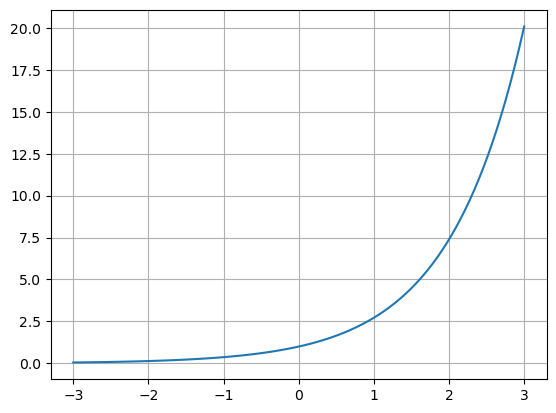

[0.88079684 0.00000027 0.11920289]
1.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)

xx = np.linspace(-3,3,100)
yy = np.exp(xx)
plt.plot(xx,yy)
plt.grid()
plt.show()

def softmax(z):
    return np.exp(z) / np.sum(np.exp(z))

z = np.array([12, -3, 10])
yhat = softmax(z)

print(yhat)
print(np.sum(yhat))

### Multinomial Logistic Regression Objective Function

<img src="images/mlr.jpeg" width="650">

define the objective likelihood function $L(\mathbf{W})$:

$$L(\mathbf{W}) = P(\mathbf{Y} \mid \mathbf{X} ; \mathbf{W}) = \prod_{i=1}^{n} P\left(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)} ; \mathbf{W}\right) = \prod_{i=1}^{n} \prod_{k=1}^{K} \left( p_k^{(i)} \right)^{y_k^{(i)}}$$

where $p_k^{(i)} = P\left(y_k^{(i)} = 1 \mid \mathbf{x}^{(i)} ; \mathbf{W}\right) = \text{softmax}\left(z_k^{(i)}\right) = \frac{e^{z_k^{(i)}}}{\sum_{j=1}^{K} e^{z_j^{(i)}}}$ and $z_k^{(i)} = \mathbf{w}_k^T \mathbf{x}^{(i)}$.

- As in the binary case, our goal is to **maximize** this likelihood function $L(\mathbf{W})$.
- The formulation $\prod_{k=1}^{K} \left(p_k^{(i)}\right)^{y_k^{(i)}}$ assumes that the probability distribution over the $K$ classes for the $i$-th sample is governed by a **Categorical distribution** (or Multinoulli distribution):

$$P\left(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)} ; \mathbf{W}\right) \sim \operatorname{Cat}(\mathbf{p}) = \prod_{k=1}^{K} p_k^{y_k^{(i)}} \quad \text{for } y_k^{(i)} \in \{0, 1\} \text{ and } \sum_{k=1}^{K} p_k = 1$$

In practice, we minimize the negative logarithm of the likelihood function $L(\mathbf{W})$, known as the **Categorical Cross-Entropy** loss function $J(\mathbf{W})$:

$$J(\mathbf{W}) = -\sum_{i=1}^{n} \sum_{k=1}^{K} y_k^{(i)} \ln \left( p_k^{(i)} \right)$$

What does this objective function reveal about the model's penalty structure?

- Consider the cost evaluated for a single training example:

$$J(\mathbf{p}, \mathbf{y} ; \mathbf{W}) = -\sum_{k=1}^{K} y_k \ln(p_k)$$

Conditioning on the true target class $c$ (where $y_c = 1$ and $y_k = 0$ for all $k \neq c$), the single-example cost simplifies directly to:

$$J(\mathbf{p}, \mathbf{y} ; \mathbf{W}) = -\ln(p_c)$$

This shows that the loss penalizes the model based exclusively on the probability assigned to the correct class $c$: as $p_c \to 1$, the penalty approaches $0$; as $p_c \to 0$, the cost grows logarithmically towards infinity ($-\ln(p_c) \to \infty$).

### Multinomial Logistic Regression in Pyhton

In [ ]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

sc = StandardScaler()
X = sc.fit_transform(X)

mlr = LogisticRegression(random_state=123, multi_class='multinomial')
mlr.fit(X, y)

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plot_decision_regions(X, y, classifier=ovr_lr)
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Logistic Regression (OvR)')

plt.subplot(1,3,2)
plot_decision_regions(X, y, classifier=ovo_lr)
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Logistic Regression (OvO)')

plt.subplot(1,3,3)
plot_decision_regions(X, y, classifier=mlr)
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.title('Multinomial Logistic Regression')
plt.show()